# Crunchyroll Anime Popularity and Ratings

## 1. Research Question

This project investigates whether highly popular anime on Crunchyroll tend to receive higher user ratings than less popular anime. Popularity is measured using the number of user votes, while ratings reflect audience evaluation of each anime.

This question matters because popularity does not always reflect quality. Understanding the relationship between popularity and ratings may help explain trends in viewer behavior and media consumption.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Hypothesis

Null Hypothesis:
There is no difference in average ratings between highly popular anime and less popular anime.

Alternative Hypothesis:
Highly popular anime have higher average ratings than less popular anime.

For this project, anime above the median number of votes will be classified as highly popular, while anime at or below the median will be classified as less popular.

## 3. Data Description

The data for this project comes from a public Kaggle dataset:
https://www.kaggle.com/datasets/filipefilardi/crunchyroll-anime-ratings

Each row in the dataset represents one anime title on Crunchyroll.

The main variables used in this analysis are:

- anime: anime title
- votes: number of user votes
- rate: user rating
- genre columns: genre indicators for each anime

The original dataset contains 1,255 anime titles.

In [2]:
anime_data = pd.read_csv("animes.csv")

print(anime_data.head())
print(anime_data.shape)

               anime                                     anime_url  \
0  Naruto Shippuuden  https://www.crunchyroll.com/naruto-shippuden   
1        Shugo Chara       https://www.crunchyroll.com/shugo-chara   
2             BLEACH            https://www.crunchyroll.com/bleach   
3             Naruto            https://www.crunchyroll.com/naruto   
4         Skip Beat!         https://www.crunchyroll.com/skip-beat   

                                           anime_img  episodes  votes  weight  \
0  https://img1.ak.crunchyroll.com/i/spire4/1c1df...       500  48518  233346   
1  https://img1.ak.crunchyroll.com/i/spire1/7c0c0...        51  33688  163641   
2  https://img1.ak.crunchyroll.com/i/spire2/52edb...       366  23900  115445   
3  https://img1.ak.crunchyroll.com/i/spire2/01453...       220  16613   79667   
4  https://img1.ak.crunchyroll.com/i/spire3/4bbe3...         0  15011   73683   

   rate  rate_1  rate_2  rate_3  ...  genre_romance  genre_sci-fi  \
0  4.81    1111     275

The first step is to examine the important variables and check for missing or invalid values.

In [3]:
print(anime_data[["votes", "rate", "episodes"]].describe())

print(anime_data[["votes", "rate"]].isna().sum())

              votes         rate     episodes
count   1255.000000  1255.000000  1255.000000
mean     343.662151     4.080940    15.175299
std     2048.070985     0.889593    43.720836
min        0.000000     0.000000     0.000000
25%       11.000000     3.730000     0.000000
50%       41.000000     4.350000    12.000000
75%      139.000000     4.690000    13.000000
max    48518.000000     5.000000  1135.000000
votes    0
rate     0
dtype: int64


Anime with zero votes or zero ratings do not provide useful information for comparing popularity and ratings, so those rows will be removed from the dataset.

In [4]:
anime_clean = anime_data[(anime_data["votes"] > 0) & (anime_data["rate"] > 0)].copy()

print(anime_clean.shape)

(1235, 41)


Next, the dataset is divided into two groups based on popularity.

Anime above the median number of votes are classified as highly popular, while anime at or below the median are classified as less popular.

In [5]:
median_votes = anime_clean["votes"].median()

anime_clean["popularity_group"] = np.where(
    anime_clean["votes"] > median_votes,
    "High popularity",
    "Low popularity"
)

print(median_votes)

print(anime_clean["popularity_group"].value_counts())

42.0
popularity_group
Low popularity     622
High popularity    613
Name: count, dtype: int64


## 4. Methods

This project uses the "Only One Test" framework discussed in class.

The test statistic is:

difference in mean ratings between highly popular anime and less popular anime

The null hypothesis states that popularity and rating are unrelated, meaning any observed difference is due to random chance.

To simulate data under the null hypothesis, the popularity labels will be randomly shuffled many times while keeping the ratings fixed. After each shuffle, the difference in mean ratings will be recalculated.

This project also uses bootstrapping to estimate uncertainty intervals for:
- the mean rating difference
- the median rating difference

The Central Limit Theorem does not directly apply to medians in the same way it applies to means, so bootstrapping is useful for estimating uncertainty for the median difference.

## 5. Exploratory Analysis and Results

The first step is exploratory data analysis and visualization.

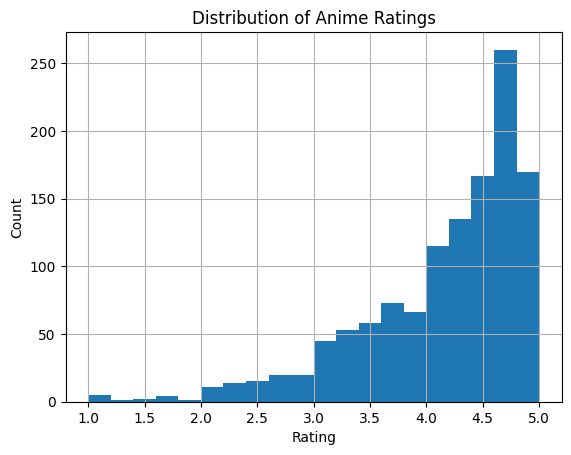

In [6]:
anime_clean["rate"].hist(bins=20)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Anime Ratings")

plt.show()

The histogram shows that most anime ratings are clustered toward the higher end of the scale.

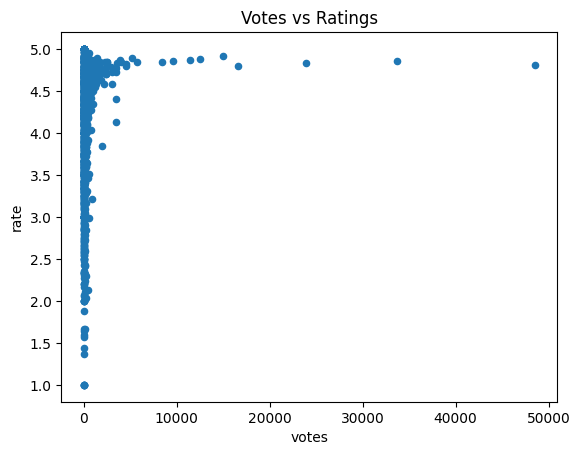

In [7]:
anime_clean.plot.scatter(x="votes", y="rate")

plt.title("Votes vs Ratings")

plt.show()

The vote distribution is strongly right-skewed, meaning a small number of anime receive very large numbers of votes.

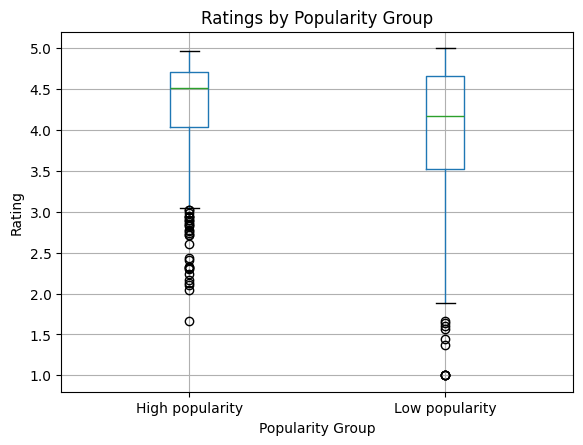

In [8]:
anime_clean.boxplot(column="rate", by="popularity_group")

plt.xlabel("Popularity Group")
plt.ylabel("Rating")
plt.title("Ratings by Popularity Group")

plt.suptitle("")

plt.show()

The boxplot suggests that highly popular anime tend to have somewhat higher ratings than less popular anime.

In [9]:
group_summary = anime_clean.groupby("popularity_group")["rate"].agg(["mean", "median", "count"])

print(group_summary)

                      mean  median  count
popularity_group                         
High popularity   4.294666   4.510    613
Low popularity    4.001527   4.175    622


Next, the observed test statistic is calculated.

In [10]:
high_mean = anime_clean[anime_clean["popularity_group"] == "High popularity"]["rate"].mean()

low_mean = anime_clean[anime_clean["popularity_group"] == "Low popularity"]["rate"].mean()

observed_diff = high_mean - low_mean

print(high_mean)
print(low_mean)
print(observed_diff)

4.294665579119086
4.001527331189711
0.2931382479293756


The observed test statistic is the difference in mean ratings between highly popular anime and less popular anime.

### Permutation Test

The permutation test simulates what differences in mean ratings would look like if popularity and ratings were unrelated.

In [11]:
np.random.seed(1)

results = []

labels = anime_clean["popularity_group"].values
ratings = anime_clean["rate"].values

for i in range(5000):

    shuffled_labels = np.random.permutation(labels)

    high_group = ratings[shuffled_labels == "High popularity"]
    low_group = ratings[shuffled_labels == "Low popularity"]

    simulated_diff = high_group.mean() - low_group.mean()

    results.append(simulated_diff)

results = np.array(results)

p_value = np.mean(results >= observed_diff)

print(p_value)

0.0


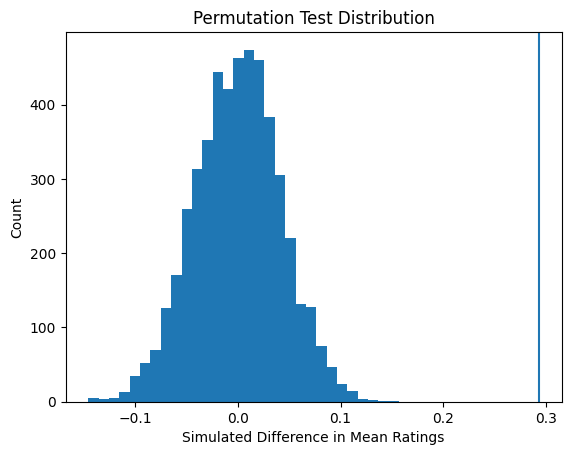

In [12]:
plt.hist(results, bins=30)

plt.axvline(observed_diff)

plt.xlabel("Simulated Difference in Mean Ratings")
plt.ylabel("Count")
plt.title("Permutation Test Distribution")

plt.show()

The permutation distribution is centered near zero, which represents what differences would look like if there were no relationship between popularity and ratings.

The observed difference falls far in the right tail of the distribution, producing a very small p-value. This suggests statistically significant evidence that highly popular anime tend to have higher ratings.

## 6. Uncertainty Estimation

Bootstrapping is used to estimate uncertainty intervals for both the mean rating difference and the median rating difference.

In [13]:
np.random.seed(2)

bootstrap_mean_diffs = []
bootstrap_median_diffs = []

for i in range(5000):

    bootstrap_sample = anime_clean.sample(
        n=len(anime_clean),
        replace=True
    )

    high = bootstrap_sample[
        bootstrap_sample["popularity_group"] == "High popularity"
    ]["rate"]

    low = bootstrap_sample[
        bootstrap_sample["popularity_group"] == "Low popularity"
    ]["rate"]

    mean_diff = high.mean() - low.mean()

    median_diff = high.median() - low.median()

    bootstrap_mean_diffs.append(mean_diff)

    bootstrap_median_diffs.append(median_diff)

mean_ci = np.percentile(
    bootstrap_mean_diffs,
    [2.5, 97.5]
)

median_ci = np.percentile(
    bootstrap_median_diffs,
    [2.5, 97.5]
)

print("Mean Difference 95% CI:")
print(mean_ci)

print("Median Difference 95% CI:")
print(median_ci)

Mean Difference 95% CI:
[0.21661657 0.37271388]
Median Difference 95% CI:
[0.24 0.44]


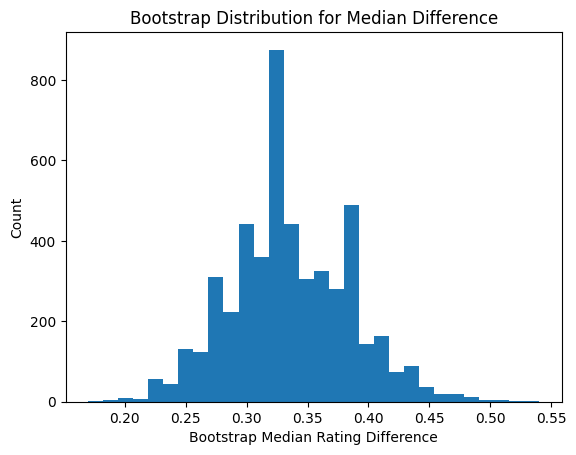

In [14]:
plt.hist(bootstrap_median_diffs, bins=30)

plt.xlabel("Bootstrap Median Rating Difference")
plt.ylabel("Count")
plt.title("Bootstrap Distribution for Median Difference")

plt.show()

The bootstrap distributions are centered above zero, which supports the conclusion that highly popular anime generally receive higher ratings.

The confidence intervals estimate a reasonable range for the true rating differences. Because the intervals remain above zero, the results support the same conclusion as the permutation test.

Bootstrapping is especially useful for the median difference because the Central Limit Theorem does not directly apply to medians in the same way it applies to means.

## 7. Limitations

This dataset only represents Crunchyroll anime and Crunchyroll users, so the results may not apply to all anime viewers.

Vote counts may also be influenced by factors unrelated to quality, such as franchise popularity, age of the anime, or marketing.

In addition, this is observational data, so the analysis can only show an association between popularity and ratings rather than proving causation.

## 8. References

Crunchyroll Anime Ratings Dataset:
https://www.kaggle.com/datasets/filipefilardi/crunchyroll-anime-ratings

Libraries used:
- pandas
- numpy
- matplotlib